# The scSpecies workflow

This tutorial demonstrates how to apply the scSpecies workflow to align three scRNA-seq datasets (mice, humans and hamsters).  

We start by loading the preprocesed `.h5mu` file saved within the `data_prepocessing.ipynb` notebook.

In [1]:
import os
import muon as mu

mu.set_options(pull_on_update=False)

path = os.path.abspath('').replace('\\', '/')+'/'
mdata = mu.read_h5mu(path+'data/liver_atlas.h5mu')

# For coloring
mdata.mod['human'].obs['cell_type_fine'] = mdata.mod['human'].obs['cell_type_fine'].cat.rename_categories({'Naive-CM CD4+ T': 'Naive/CM CD4+ T'})

Before we pre-train scSpecies, we plot a UMAP representation of the unaligned mouse/human dataset pair on the data-level. 

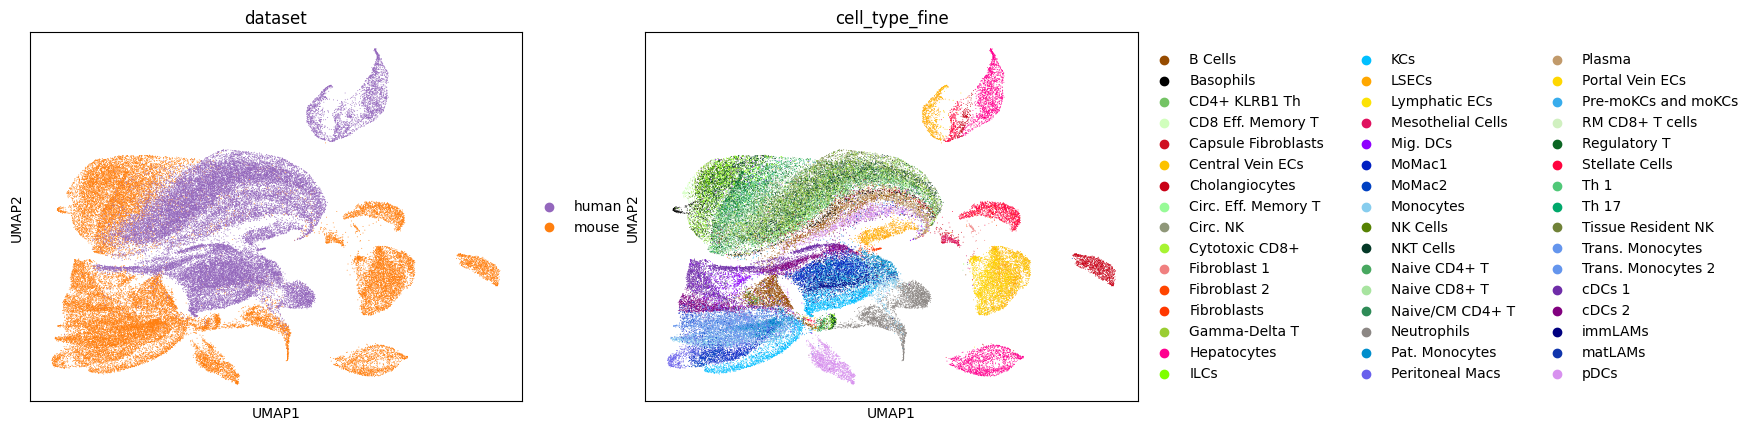

In [2]:
from scipy import sparse
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np

from scspecies.plot import return_palette
from scspecies.models import neighbors_workaround

# Subsetting to homologous genes
_, hom_ind_mouse, hom_ind_human = np.intersect1d(mdata.mod['mouse'].var_names, mdata.mod['human'].var['var_names_transl'], return_indices=True)

adata_concat = ad.AnnData(
    X=sparse.vstack([mdata.mod['mouse'][:, hom_ind_mouse].X, mdata.mod['human'][:, hom_ind_human].X]).toarray(),
    obs=pd.concat([mdata.mod['mouse'].obs, mdata.mod['human'].obs])
).copy()

# Color scheme for the liver cell dataset. Won't return nice results for other datasets.
palette = return_palette(list(adata_concat.obs.cell_type_fine.unique()) + list(adata_concat.obs.dataset.unique()))

sc.pp.pca(adata_concat) 

sc.pp.neighbors(adata_concat, use_rep='X_pca')
# sc.pp.neighbors can crash the kernel for M1/M2 chips. In this case use a workaroung for this function.
#neighbors_workaround(adata_concat, use_rep='X_pca')


sc.tl.umap(adata_concat)
sc.pl.umap(adata_concat, color=['dataset', 'cell_type_fine'], palette=palette)

## 1) Context and target dataset alignment

We start by aligning the mouse and human scRNA-seq datasets using scSpecies.  
We use the mouse dataset as context for the human target dataset.  
We define the corresponding context and target scVI models by instantiating the `scSpecies` class.   

In [3]:
from scspecies.models import scSpecies
import torch

device = ("mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built() else "cuda" if torch.cuda.is_available() else "cpu")

model = scSpecies(device, 
                mdata, 
                path,
                context_key = 'mouse', 
                target_key = 'human',
                random_seed=1234                          
                )
                

Initializing context scVI model.
Initializing target scVI model.


First, we pre-train context scVI model with `train_context` for 30 epochs and save the model parameters to path.  
Afterwards, we calculate latent and intermediate representations with `get_representation` an save them in the context modality in the `.obsm` layer.  
Intermediate representations are also saved and later used during fine-tuning for alignment.

In [4]:
model.train_context(30, save_key='_mouse')
model.get_representation(eval_model='context', save_intermediate=True, save_libsize=True)

Pretraining on the context dataset for 30 epochs (= 8820 iterations).
Progress: 99.8% - ETA: 0:00:00 - Epoch: 30 - Iteration: 8800 - ms/Iteration: 15.80 - nELBO: 1461.4 (+1.410) - nlog_likeli: 1443.2 (+1.366) - KL-Div z: 15.140 (+0.023) - KL-Div l: 3.0712 (+0.022).           Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/config_dict.pkl
Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/context_config__mouse.pkl
Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/context_optimizer__mouse.opt
Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/target_encoder_inner__mouse.pth.
Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/context_encoder_outer__mouse.pth.
Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/context_decoder__mouse.pth.
Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/context_lib_encoder__mouse

We check that the context scVI model has separated latent cell clusters by visualizing the latent representation with UMAP.

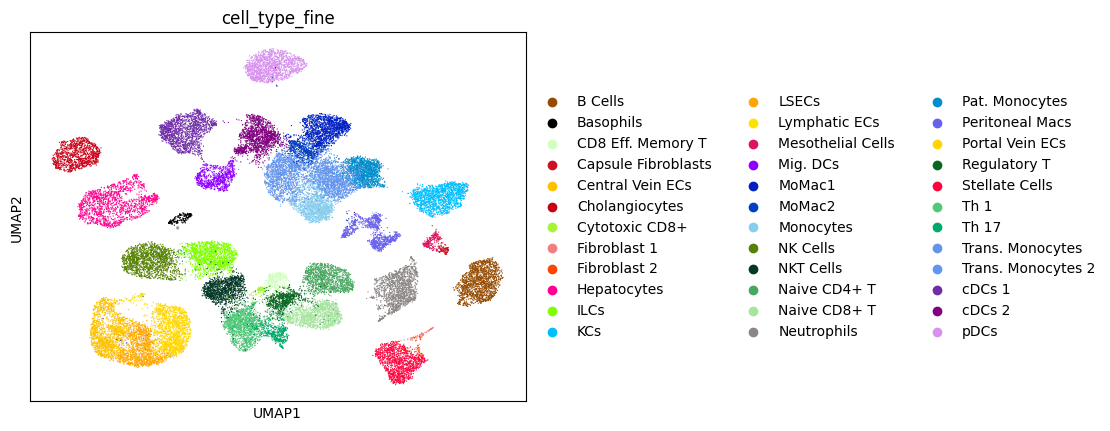

In [5]:
sc.pp.neighbors(model.mdata['mouse'], use_rep='z_mu')
#neighbors_workaround(model.mdata['mouse'], use_rep='z_mu')

sc.tl.umap(model.mdata['mouse'])
sc.pl.umap(model.mdata['mouse'], color='cell_type_fine', palette=palette)

Next we fine-tune by training the target scVI model and aligning the human dataset with this latent representations.

In [6]:
model.train_target(30, save_key='_human')
model.get_representation(eval_model='target', save_libsize=True)

Training on the target dataset for 30 epochs (= 8190 iterations).
Progress: 100.0% - ETA: 0:00:00 - Epoch: 30 - Iteration: 8187 - ms/Iteration: 36.19 - nELBO: 1847.1 (+0.706) - nlog_likeli: 1384.8 (+0.496) - KL-Div z: 13.803 (+0.006) - KL-Div l: 2.8112 (+0.021) - Align-Term: 445.69 (+0.183).           Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/config_dict.pkl
Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/target_config__human.pkl
Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/target_optimizer__human.opt
Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/target_encoder_inner__human.pth.
Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/target_encoder_outer__human.pth.
Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/target_decoder__human.pth.
Saved /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/tar

After fine-tuning, we can visualize the aligned latent representation.   

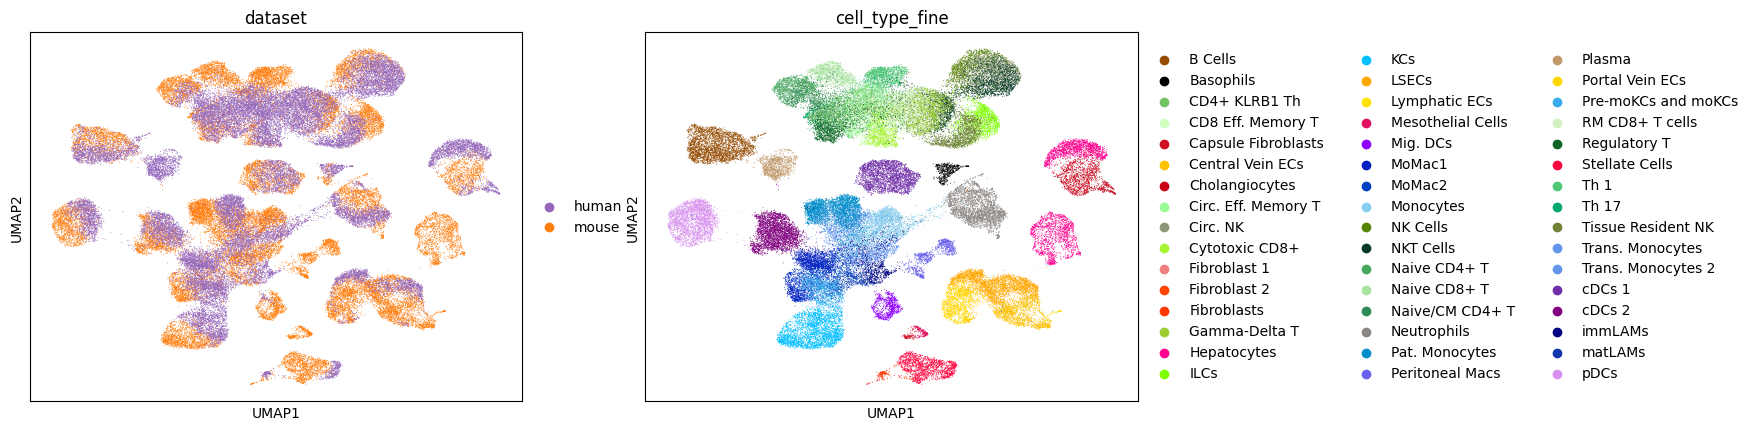

In [7]:
adata_concat.obsm['lat_rep'] = np.concat([mdata.mod['mouse'].obsm['z_mu'], mdata.mod['human'].obsm['z_mu']])

sc.pp.neighbors(adata_concat, use_rep='lat_rep') 
#neighbors_workaround(adata_concat, use_rep='lat_rep')
sc.tl.umap(adata_concat)

sc.pl.umap(adata_concat, color=['dataset', 'cell_type_fine'], palette=palette)

## 2) Information transfer via similarity scores

We continue by evaluating the likelihood based similarity measure between target and context cell types with `return_similarity_df_prot`.   

When `scale=min_max` or `scale=max` the scores are scaled such that the values can be interpreted as 1 = most similar. 
Without scaling the highest values (closest to zero) represent high similarity.
The output dataframe contains target cell types in `df.index` and context cell types in `df.columns`.  
The values should be interpreted row-wise and contain the similarity of a target cell type with the corresponding context cell types.

We can use these similarity scores to match cell type annotation between datasets.
To reduce computational demand reduce the sample size via `max_sample_targ` and `max_sample_cont`.

1152/1152 Similarity calculation for the pDCs-pDCs pair                                                                                                    B Cells   Basophils  CD8 Eff. Memory T  \
B Cells            -3.551205 -347.071991        -205.805511   
Basophils        -367.502869   -6.766159        -367.215576   
CD4+ KLRB1 Th    -215.161743 -271.281860         -78.929642   
Central Vein ECs -322.188660 -700.436768        -326.259460   
Cholangiocytes   -499.112000 -485.331177        -334.543152   

                  Capsule Fibroblasts  Central Vein ECs  Cholangiocytes  \
B Cells                   -194.542191       -367.720825     -181.570511   
Basophils                 -294.482727       -346.947021     -234.808044   
CD4+ KLRB1 Th             -171.188400       -399.845886     -157.499298   
Central Vein ECs          -422.906860        -49.124344     -588.992798   
Cholangiocytes            -310.032990       -401.235352      -18.102785   

                  Cytotoxic CD8+  Fi

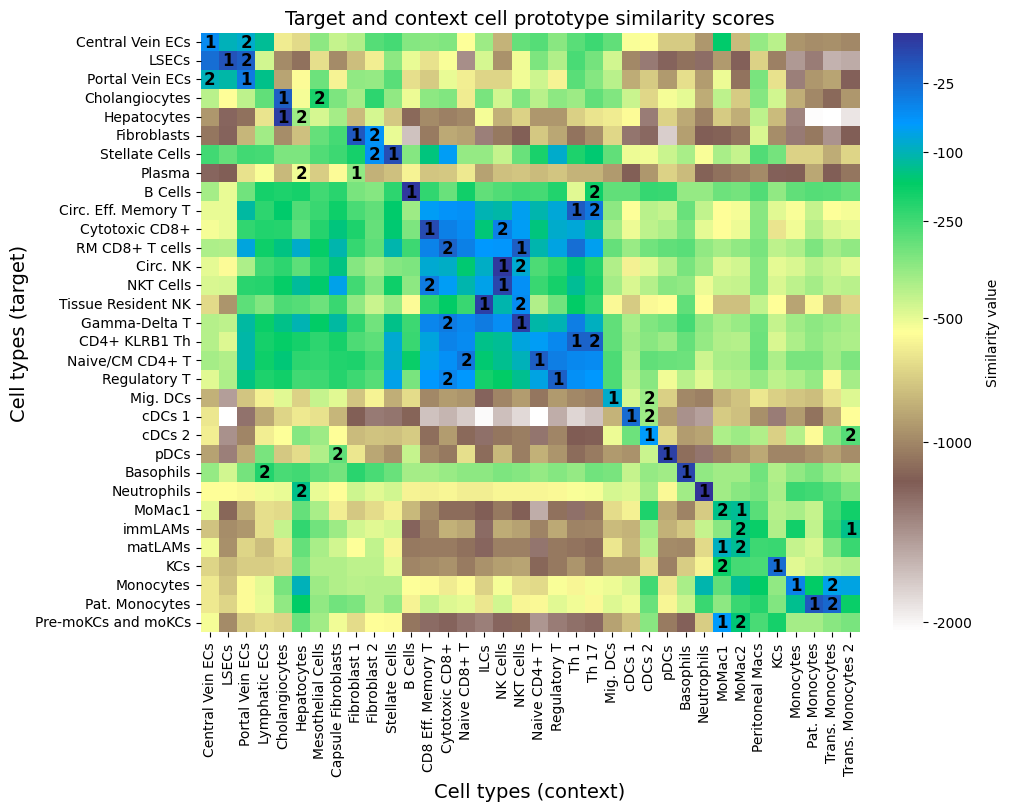

In [8]:
from scspecies.plot import plot_prototype_sim_heatmap

import matplotlib.pyplot as plt
import seaborn as sns

df = model.return_similarity_df()
print(df.head())

plot_prototype_sim_heatmap(df)    

We can use the similarity measure to infer target label annotation from context cells.

We draw a random target cell index and calculate similarity scores for all context cells with `transfer_labels_cell`.  
We transfer the context `.obs` labels specified in `context_obs_transfer`.  
The `df_neigbor` dataframe contains all context cells with corresponding indices sorted by similarity.  
The labels can be transferred via majority vote based on the occurence in the top-k most similar cells.  

We can plot the similarity scores for the whole dataset using `plot_similarity`.   
For cell type label coloring refer to the aligned latent space visualization.
Green colors indicate the similar cells while the target cell is marked by a black cross.

Index of target human cell: 19573, Information: cell_type_coarse: M, cell_type_fine: o.
                            cell_type_coarse      cell_type_fine  index  \
GCAGCCATCGTGGGAA-46_mouse  Mono-Mono Derived  Trans. Monocytes 2  30597   
CGGACTGGTGACTCAT-42_mouse  Mono-Mono Derived  Trans. Monocytes 2  30881   
TCAATCTCATTTGCCC-41_mouse  Mono-Mono Derived  Trans. Monocytes 2  31607   
CCTCTGATCGGTTCGG-46_mouse  Mono-Mono Derived  Trans. Monocytes 2  31386   
CTCTAATCACCATGTA-41_mouse  Mono-Mono Derived  Trans. Monocytes 2  31559   

                           similarity_score  
GCAGCCATCGTGGGAA-46_mouse          5.018066  
CGGACTGGTGACTCAT-42_mouse          7.247314  
TCAATCTCATTTGCCC-41_mouse          7.400024  
CCTCTGATCGGTTCGG-46_mouse          7.458252  
CTCTAATCACCATGTA-41_mouse          8.483887  


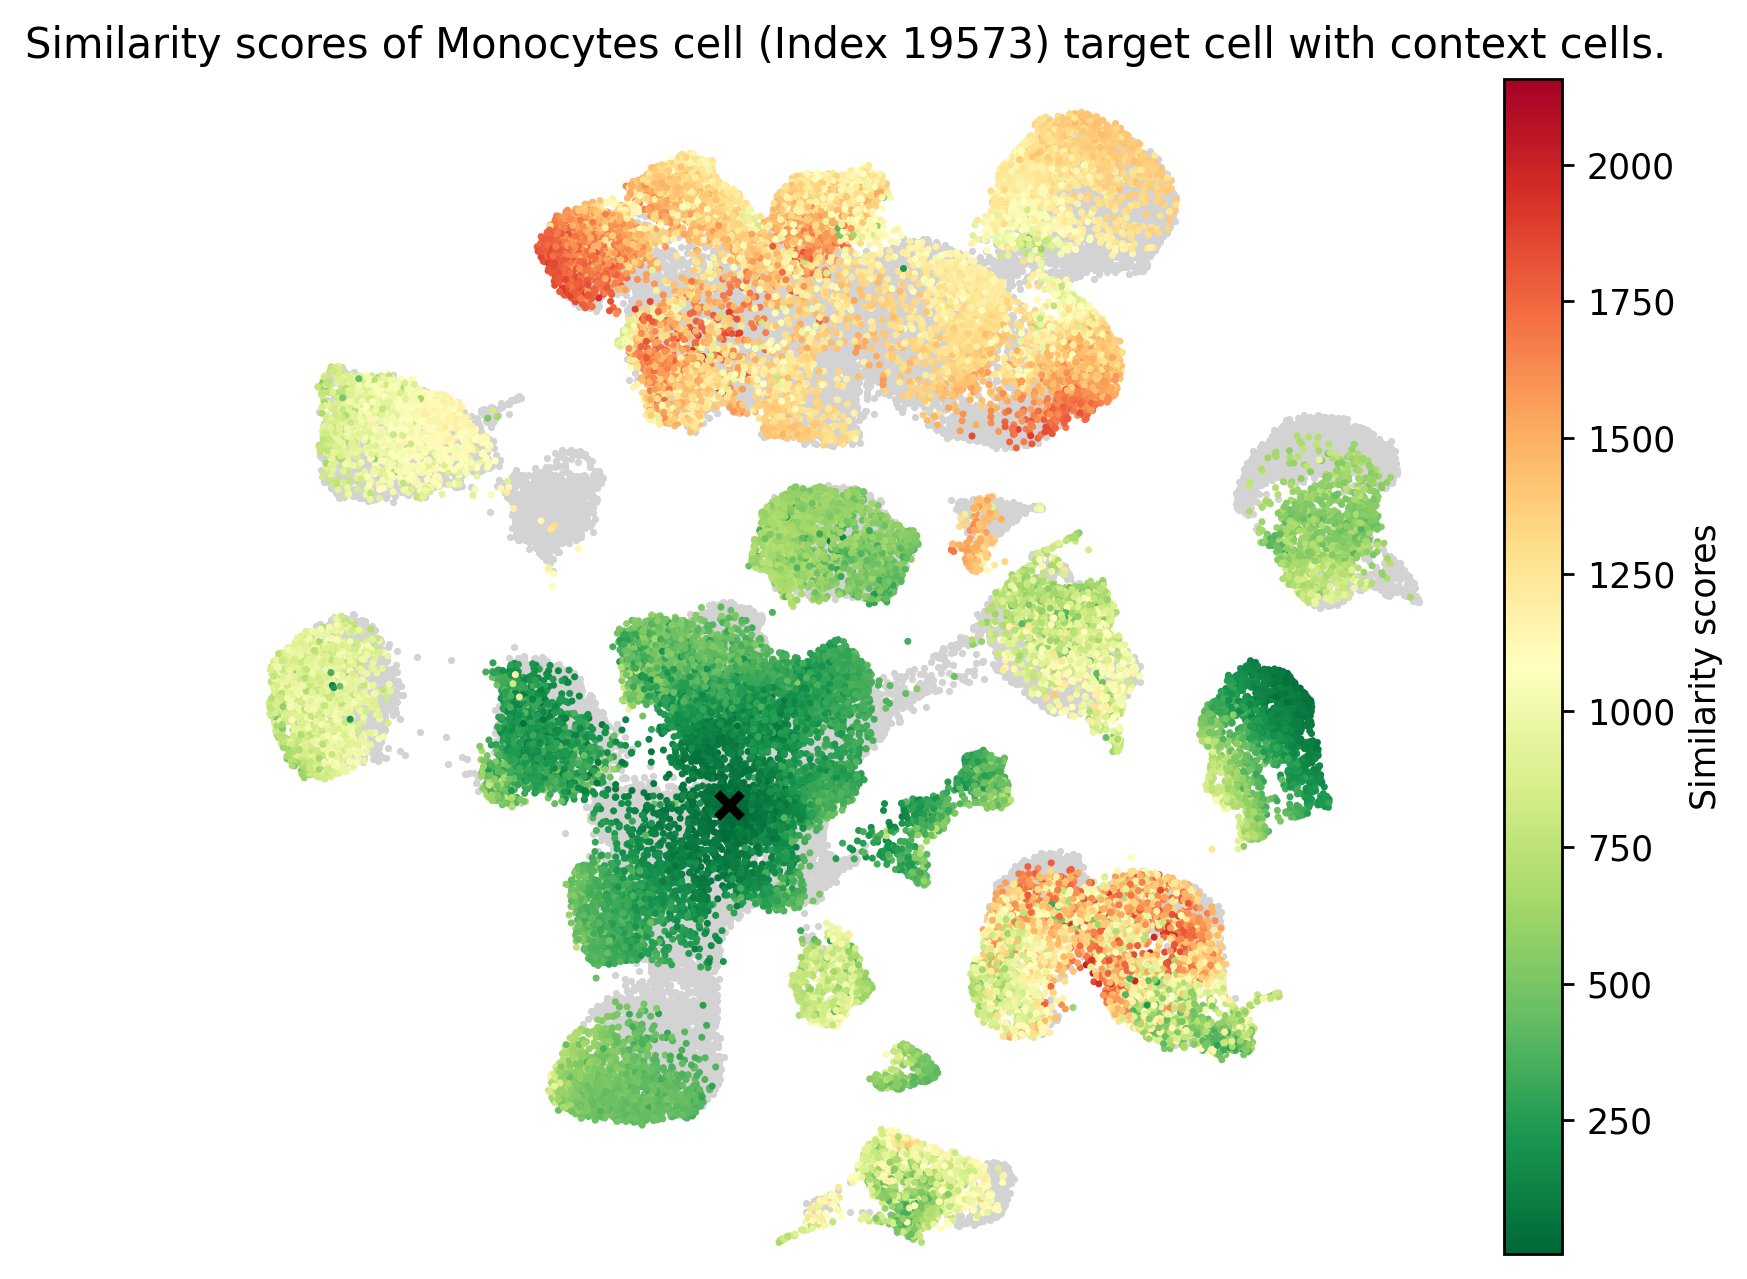

In [9]:
from scspecies.plot import plot_similarity

human_cell_types = model.mdata['human'].obs['cell_type_fine']
mouse_cell_types = model.mdata['mouse'].obs['cell_type_fine']
common_cell_types = np.intersect1d(human_cell_types.unique(), mouse_cell_types.unique())

human_inds = human_cell_types.isin(common_cell_types).to_numpy().nonzero()[0]
human_ind = np.random.choice(human_inds)

context_obs_transfer = ['cell_type_coarse', 'cell_type_fine']
df_neigbor = model.transfer_labels_cell(human_ind, context_obs_transfer)

print('Index of target human cell: {}, Information: {}.'.format(str(human_ind), ', '.join([obs_name+': '+label for label, obs_name in zip(model.mdata['human'].obs[context_obs_transfer].iloc[human_ind].values[0], context_obs_transfer)])))
print(df_neigbor.head())

plot_similarity(adata_concat, df_neigbor, human_ind)

Next, we perform this process for the whole dataset using `transfer_labels_dataset`.  
This transfers the specified context labels for the whole dataset and saves the predictions to the `.obs` layer of the target dataset.  
Afterwards, we can compute a normalized confusion matrix (%) and the total balanced accuracy for label transfer with `ret_pred_df`.   
We compare this against the results of the data-level neighbor search.

In [10]:
context_obs_transfer = ['cell_type_coarse', 'cell_type_fine']
model.transfer_labels_data(context_obs_transfer)
print(model.mdata['human'].obs[['pred_sim_cell_type_coarse', 'cell_type_coarse', 'pred_sim_cell_type_fine', 'cell_type_fine']].head())

df_nns, bas_nns = model.ret_pred_df(pred_key='pred_nns_cell_type_fine', target_label_key='cell_type_fine', context_label_key='cell_type_fine')
df_sim, bas_sim = model.ret_pred_df(pred_key='pred_sim_cell_type_fine', target_label_key='cell_type_fine', context_label_key='cell_type_fine')

print(df_sim.head())
print('Data-level k=25 nearest neighbor search --> Balanced accuracy: {}%'.format(round(bas_nns*100,2)))
print('Label tarnsfer using similarity measure --> Balanced accuracy: {}%'.format(round(bas_sim*100,2)))

Pre-computing latent space NNS with 250 neighbors using the euclidean distance.
Calculate similarity metric. Step 273/274.                          pred_sim_cell_type_coarse   cell_type_coarse  \
TTCGGTCCACGGCCAT-12_human         Mono-Mono Derived  Mono-Mono Derived   
TCATTTGCAGTCAGAG-1_human          Mono-Mono Derived  Mono-Mono Derived   
TAGTTGGCATCCCACT-4_human          Mono-Mono Derived  Mono-Mono Derived   
GGATTACTCCTCGCAT-12_human         Mono-Mono Derived  Mono-Mono Derived   
TGGTAGTGTGGCTACC-28_human         Mono-Mono Derived  Mono-Mono Derived   

                          pred_sim_cell_type_fine       cell_type_fine  
TTCGGTCCACGGCCAT-12_human                  MoMac1  Pre-moKCs and moKCs  
TCATTTGCAGTCAGAG-1_human                   MoMac1  Pre-moKCs and moKCs  
TAGTTGGCATCCCACT-4_human                   MoMac1  Pre-moKCs and moKCs  
GGATTACTCCTCGCAT-12_human                  MoMac1  Pre-moKCs and moKCs  
TGGTAGTGTGGCTACC-28_human                  MoMac1  Pre-moKCs and moK

/Users/cschaech/anaconda3/envs/scspecies-env2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/Users/cschaech/anaconda3/envs/scspecies-env2/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


                  B Cells  Basophils  CD8 Eff. Memory T  Capsule Fibroblasts  \
B Cells              96.6   0.000000           0.000000                  0.0   
Basophils             0.0  91.578947           0.000000                  0.0   
CD4+ KLRB1 Th         0.0   0.000000           0.066667                  0.0   
Central Vein ECs      0.0   0.000000           0.000000                  0.0   
Cholangiocytes        0.0   0.000000           0.000000                  0.0   

                  Central Vein ECs  Cholangiocytes  Cytotoxic CD8+  \
B Cells                        0.0             0.0        0.000000   
Basophils                      0.0             0.0        0.000000   
CD4+ KLRB1 Th                  0.0             0.0        2.333333   
Central Vein ECs              98.0             0.0        0.000000   
Cholangiocytes                 0.0           100.0        0.000000   

                  Fibroblast 1  Fibroblast 2  Hepatocytes  ...  \
B Cells                    0.0  

We compare the results visually by generateing a bar plot that indicates label transfer improvement over the data level NNS.  
For each target cell type the data NNS accuracy is displayed in the top row and the similarity based label transfer accuracy in the bottom row.  
The improvement in % is displayed at the right.  

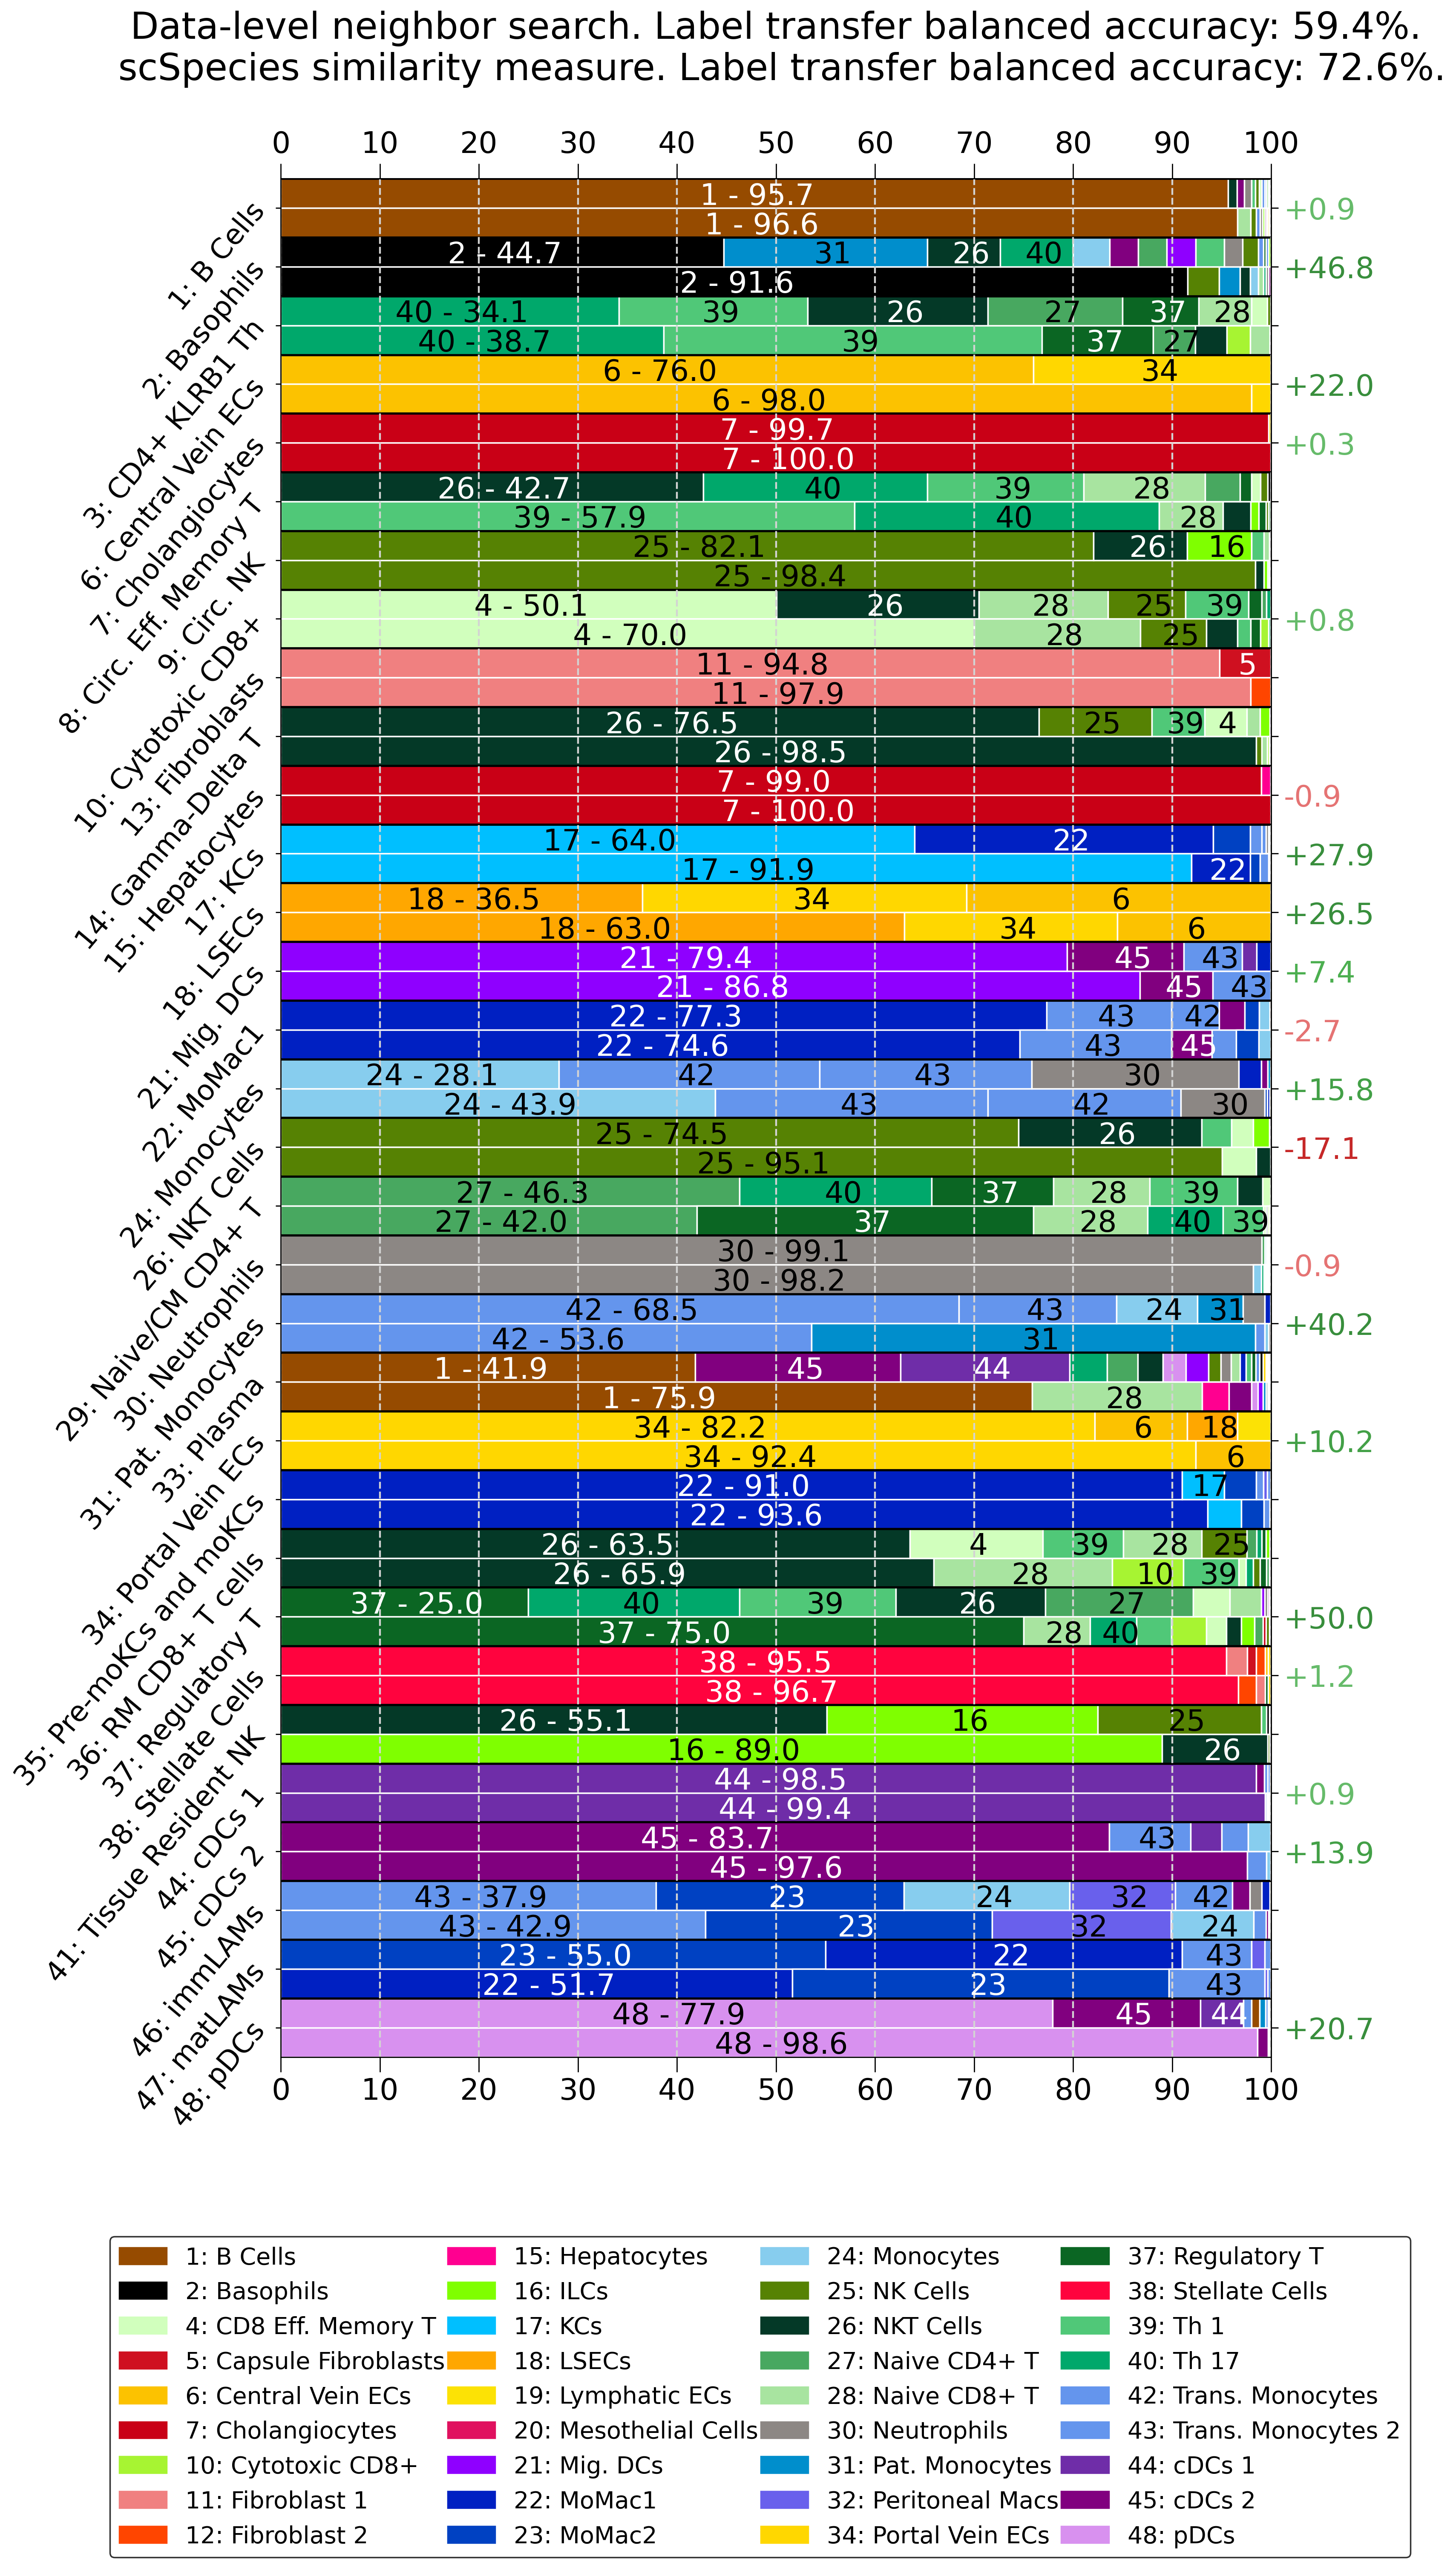

In [11]:
from scspecies.plot import label_transfer_acc

label_transfer_acc(df_nns, df_sim)

## 3) Differential gene expression analysis

The difference in modeled gene expression can be analyzed by comparing the log2-fold change in normalized gene expression with `compute_logfold_change`.  

In [12]:
lfc_dict = model.compute_logfold_change(lfc_delta = 1)

The output is a dictionary with cell type wise data frames containing logfoldchange values and other information.
The dataframes contain the homologous traget gene symbols in their index and their chosen labels as columns. 

- `rho_median_context` : Contains median context normalized gene expression, 
- `mu_median_context` : Contains median context expected value gene expression,  
- `rho_median_target` : Contains median target normalized gene expression,  
- `mu_median_target` : Contains median target expected value gene expression,  
- `lfc` : Contains mMedian Log2 fold-change of the relative expression parameter rho,
- `p` : Probability of Log2 fold-change values greater than `lfc_delta`,
- `lfc_rand` : Contains median Log2 fold-change of the relative expression parameter rho on permuted data,
- `p_rand` : Probability of Log2 fold-change values greater than `lfc_delta` on permuted data. 

In [13]:
print('Results for', list(lfc_dict.keys())[0])
lfc_dict[list(lfc_dict.keys())[0]].head()

Results for B Cells


,rho_median_context,mu_median_context,rho_median_target,mu_median_target,lfc,p,lfc_rand,p_rand
C12orf75,1.206251e-07,0.000181,0.000089,0.123426,6.322998,1.000000,-5.483539,1.000000
C1orf21,6.015457e-06,0.009070,0.000006,0.007996,-0.119253,0.021987,-4.536520,1.000000
C19orf33,2.811825e-05,0.041576,0.000001,0.001560,-3.784217,1.000000,-5.864892,1.000000
KIAA0513,1.824987e-05,0.028230,0.000008,0.012216,-1.027371,0.539969,0.696235,0.173268
C19orf38,5.501264e-04,0.839834,0.000026,0.036723,-4.331485,1.000000,-4.134716,1.000000


We can visualize the results with `plot_lfc` per cell type.

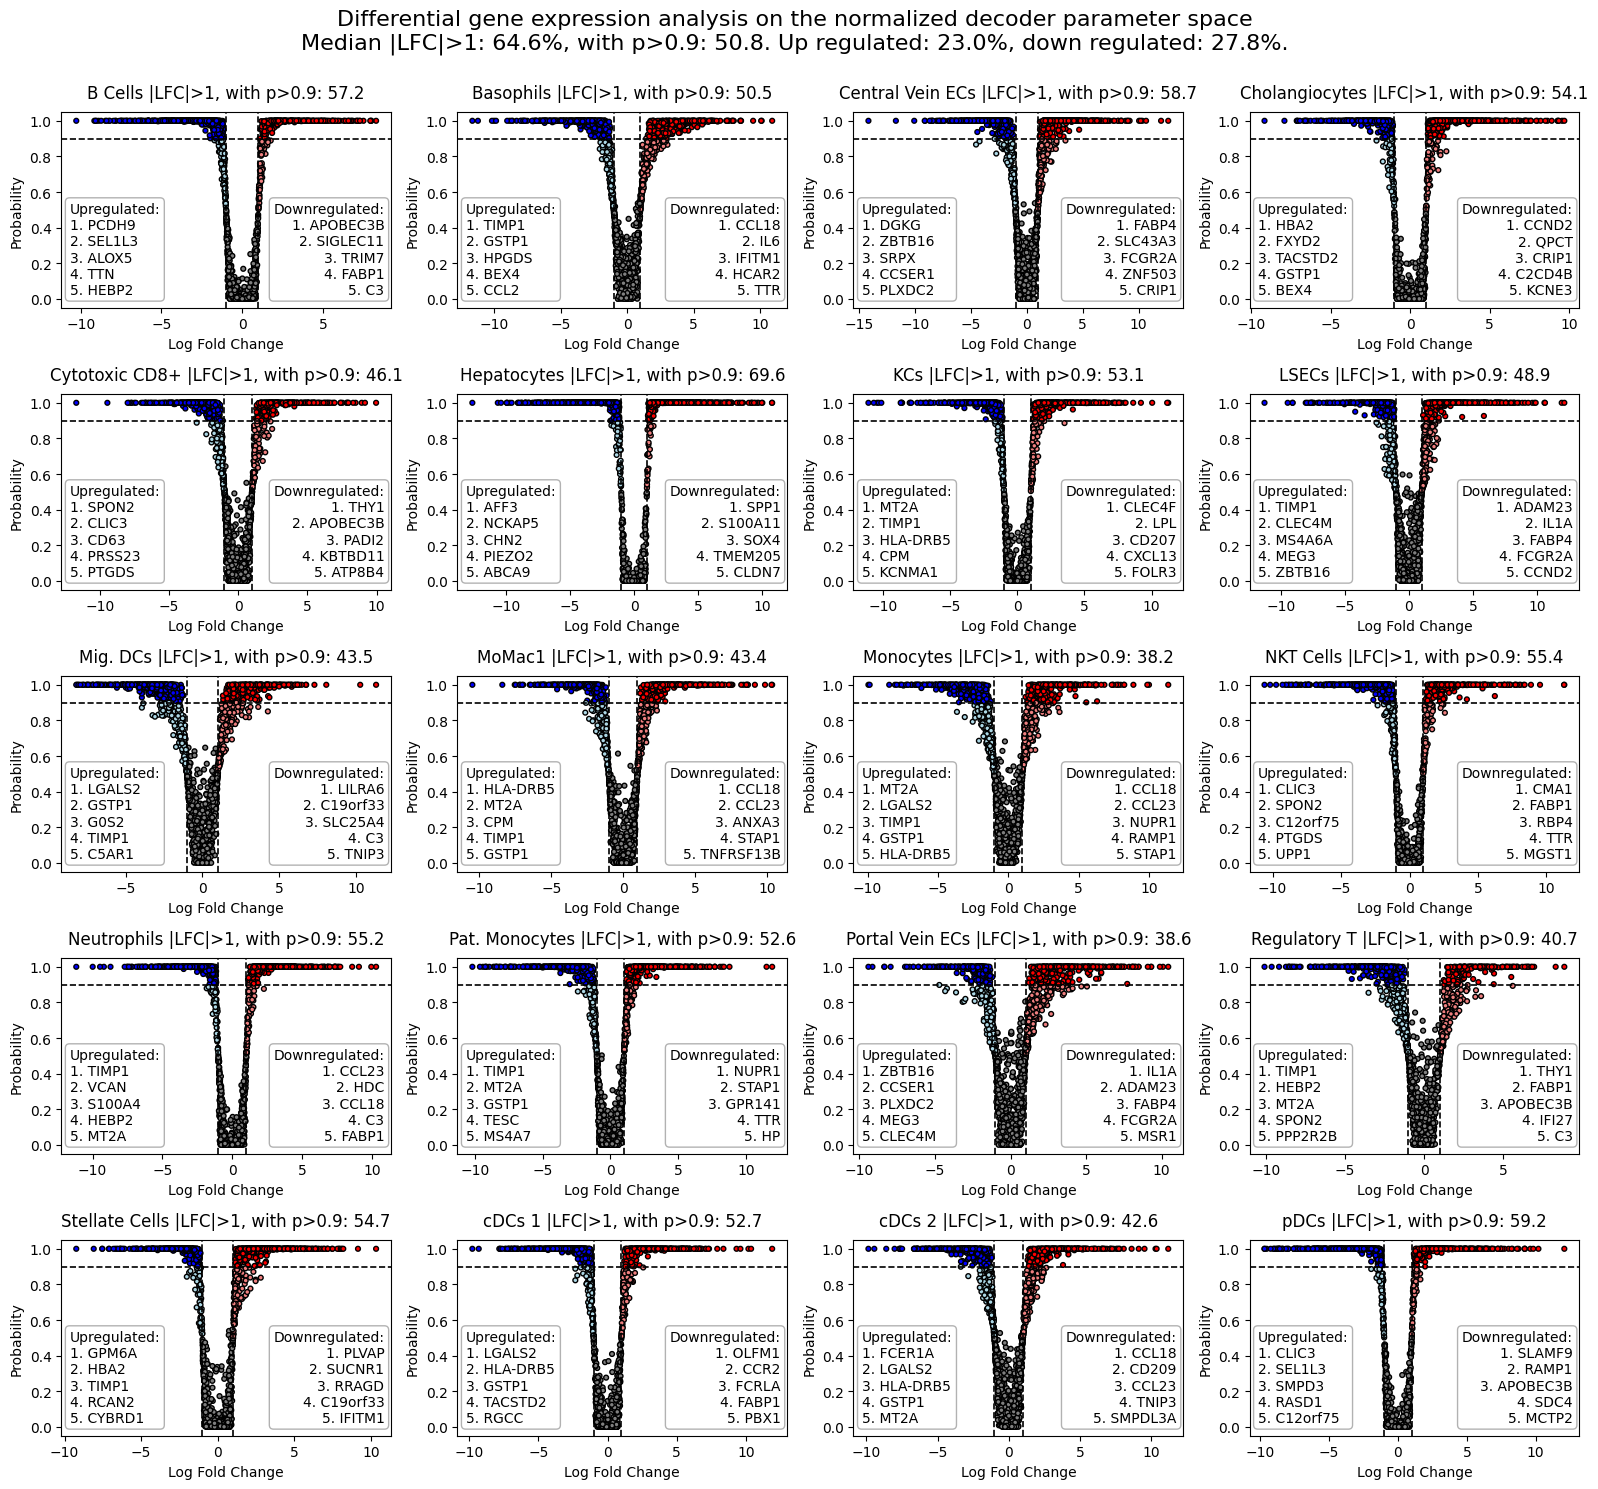

In [14]:
from scspecies.plot import plot_lfc

plot_lfc(lfc_dict)

Lets compare the results with a DFG Analysis at the data level. 
For this we generate homologous cell samples from the latent space.

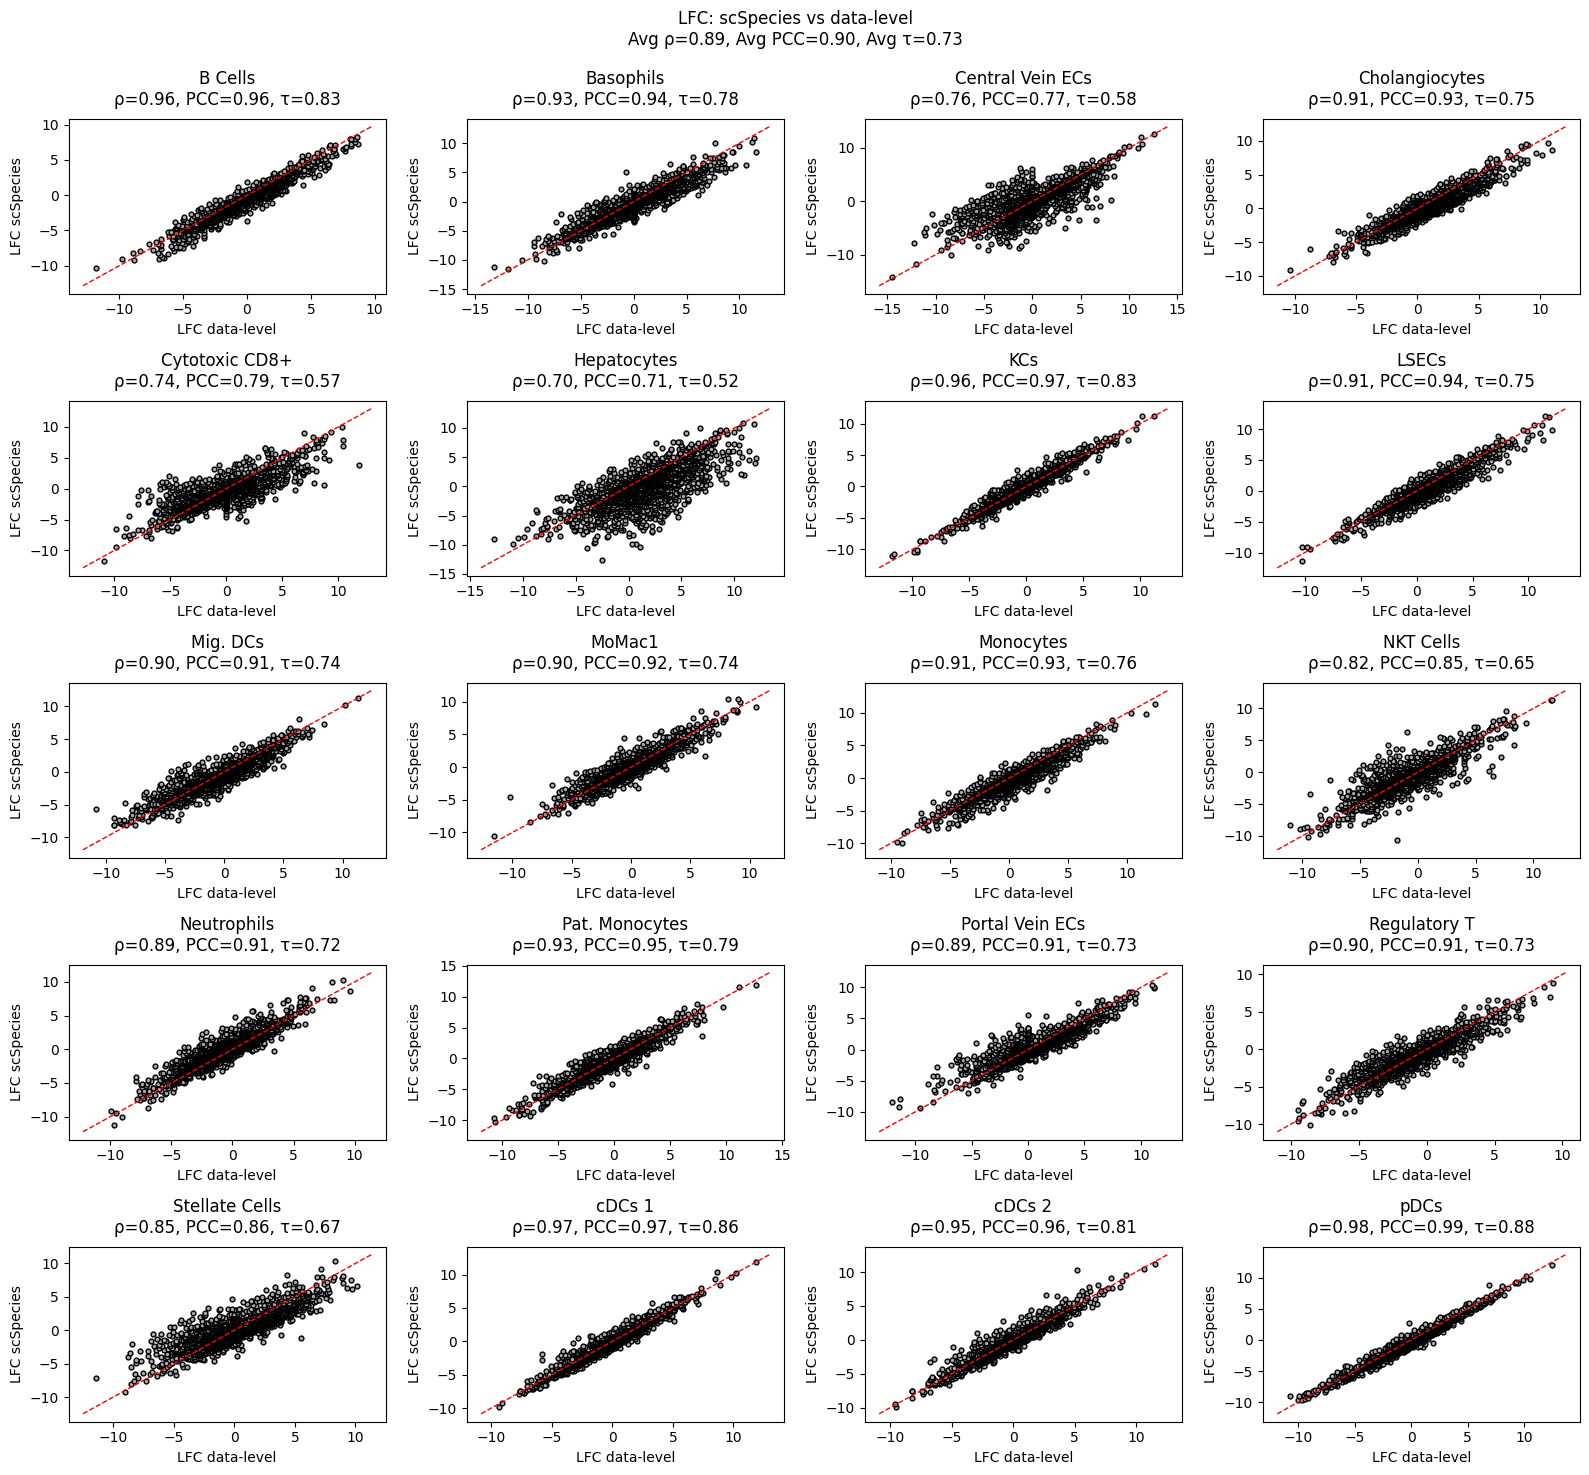

In [15]:
from scspecies.plot import plot_lfc_comparison

target_rho_dict, context_rho_dict = model.generate_homologous_samples(samples=2000)
plot_lfc_comparison(model, lfc_dict)    

## 4) Creating a cell atlas

Finally, we can also create a multi-species cell atlas by aligning a hamster scVI archtecture to the same mouse context model.   
We instantiate a second model and load the encoder parameters of the context encoder.

NOTE: For differential gene expression analysis the context decoder should be retrained.  

In [17]:
# Just for coloring
mdata.mod['human'].obs['cell_type_coarse'] = mdata.mod['human'].obs['cell_type_coarse'].cat.rename_categories({'Mono-Mono Derived': 'Mono/Mono Derived'})
mdata.mod['mouse'].obs['cell_type_coarse'] = mdata.mod['mouse'].obs['cell_type_coarse'].cat.rename_categories({'Mono-Mono Derived': 'Mono/Mono Derived'})
mdata.mod['hamster'].obs['cell_type_coarse'] = mdata.mod['hamster'].obs['cell_type_coarse'].cat.rename_categories({'Mono-Mono Derived': 'Mono/Mono Derived'})
mdata.mod['human'].obs['cell_type_coarse'] = mdata.mod['human'].obs['cell_type_coarse'].cat.rename_categories({'NK-NKT cells': 'NK/NKT cells'})
mdata.mod['mouse'].obs['cell_type_coarse'] = mdata.mod['mouse'].obs['cell_type_coarse'].cat.rename_categories({'NK-NKT cells': 'NK/NKT cells'})
mdata.mod['hamster'].obs['cell_type_coarse'] = mdata.mod['hamster'].obs['cell_type_coarse'].cat.rename_categories({'NK-NKT cells': 'NK/NKT cells'})

model_hamster = scSpecies(device, 
                mdata, 
                path,
                context_key = 'mouse', 
                target_key = 'hamster',                                                   
                )

model_hamster.load('context', save_key='_mouse')

model_hamster.train_target(25, save_key='_hamster')
model_hamster.get_representation(eval_model='target', save_libsize=True)


Initializing context scVI model.
Initializing target scVI model.
Loaded /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/config_dict.pkl
Loaded /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/context_config__mouse.pkl
Loaded /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/context_optimizer__mouse.opt
Loaded /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/context_encoder_outer__mouse.pth
Loaded /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/context_decoder__mouse.pth
Loaded /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/target_encoder_inner__mouse.pth
Loaded /Users/cschaech/Desktop/scpecies_package/docs/source/tutorials/params/context_lib_encoder__mouse.pth
Training on the target dataset for 25 epochs (= 1150 iterations).
Progress: 99.7% - ETA: 0:00:00 - Epoch: 25 - Iteration: 1146 - ms/Iteration: 33.36 - nELBO: 1752.2 (+2.446) - nlog_likeli: 1264.0 (-1.23

Visualizing the aligned latent space

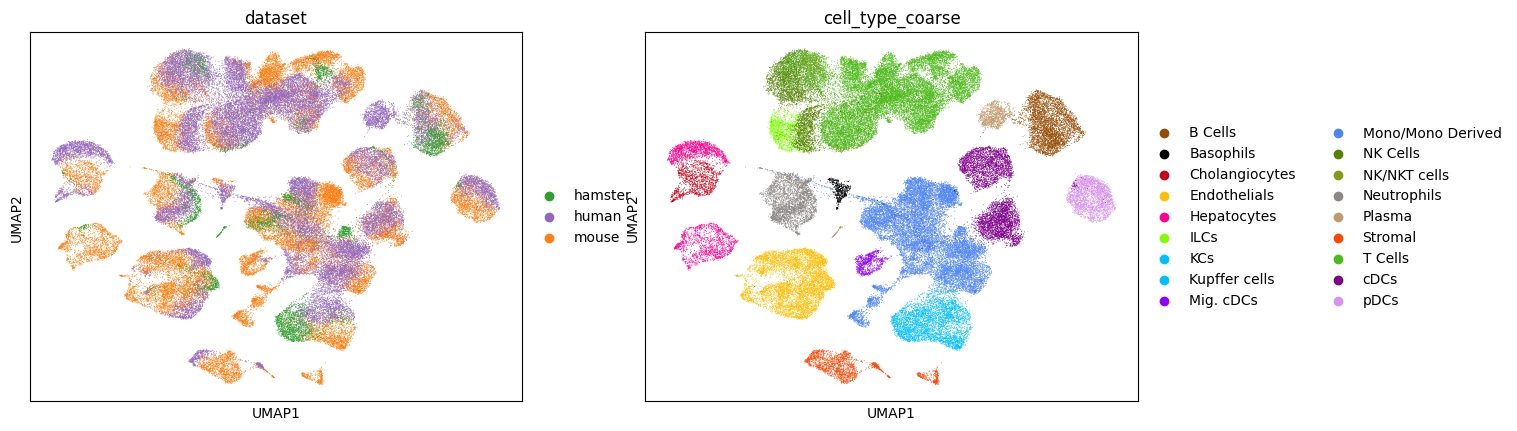

In [18]:
adata_concat = ad.AnnData(
    X=sparse.vstack([mdata.mod['mouse'].obsm['z_mu'], mdata.mod['human'].obsm['z_mu'], mdata.mod['hamster'].obsm['z_mu']]).toarray(),
    obs=pd.concat([mdata.mod['mouse'].obs[['dataset', 'cell_type_coarse']], mdata.mod['human'].obs[['dataset', 'cell_type_coarse']], mdata.mod['hamster'].obs[['dataset', 'cell_type_coarse']]])
)

# Color scheme for the liver cell dataset. Won't return nice results for other datasets.
palette = return_palette(list(adata_concat.obs.cell_type_coarse.unique()) + list(adata_concat.obs.dataset.unique()))

sc.pp.neighbors(adata_concat)
#neighbors_workaround(adata_concat)
sc.tl.umap(adata_concat)

sc.pl.umap(adata_concat, color=['dataset', 'cell_type_coarse'], palette=palette)